In [1]:
import pandas as pd

df=pd.read_csv('../data/raw/DuplicateQuestion.csv')

df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [2]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
290641,290641,411956,411957,"What is the weight of Suburban, LHB and ICF co...",Why do LHB coaches use generators while the al...,0
11017,11017,21304,21305,What is the difference between luck and fate?,What is the most amazing thing that happened t...,0
238376,238376,349722,349723,How did you learn to accept that life is not f...,Why do we accept the premise that life is not ...,0
389549,389549,522038,522039,Is it possible that Hawking radiation is matte...,Protons and neutrons can be broken down into q...,0
49485,49485,88069,88070,I am an NITian of cgpi below 7 in ECE and in 3...,I am a 1st year student of ECE in NIT Jamshedp...,0


In [3]:
df.shape

(404290, 6)

In [4]:
df.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'], dtype='object')

In [5]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [6]:
df=df.sample(100000,random_state=42)

In [7]:
df.shape

(100000, 6)

In [8]:
df.isnull().sum()


id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [9]:
df.to_csv(
    '../data/processed/sample_50k.csv'
)

In [10]:
df['is_duplicate'].value_counts()

is_duplicate
0    62879
1    37121
Name: count, dtype: int64

<Axes: xlabel='is_duplicate'>

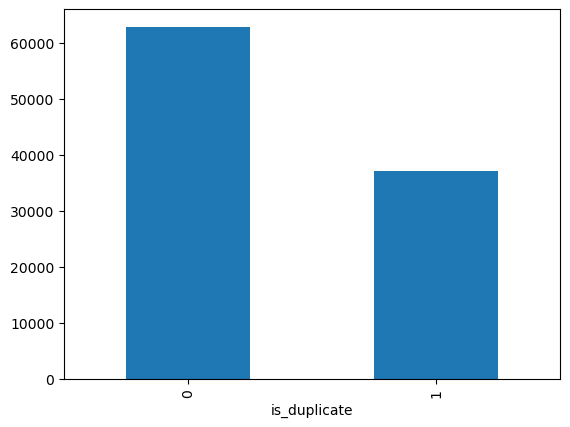

In [12]:
import matplotlib.pyplot as plt

df['is_duplicate'].value_counts().plot(kind='bar')

# making class balanced

In [13]:
#split the data set

df_0=df[df['is_duplicate']==0]
df_1=df[df['is_duplicate']==1]

In [14]:
#downsample class 0 to match class 1

df_0_sample=df_0.sample(n=len(df_1),random_state=42)

In [15]:
df_balanced=pd.concat([df_0_sample,df_1])

In [16]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [17]:
df_balanced["is_duplicate"].value_counts()

is_duplicate
1    37121
0    37121
Name: count, dtype: int64

In [18]:
df=df_balanced

<Axes: xlabel='is_duplicate'>

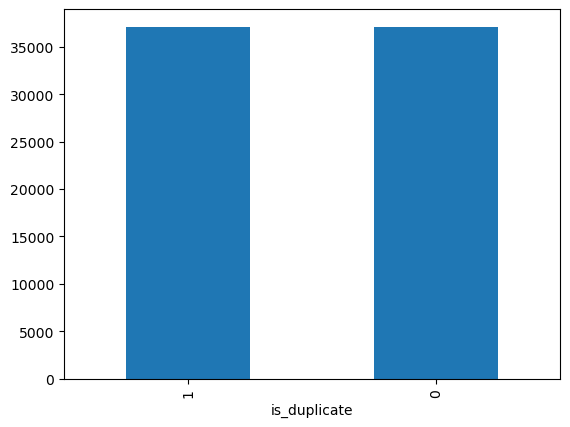

In [19]:
import matplotlib.pyplot as plt

df['is_duplicate'].value_counts().plot(kind='bar')

In [20]:
#observing some duplicate examples

duplicates=df[df['is_duplicate']==1]

duplicates[['question1','question2']].head(10)

,question1,question2
0,The twins (Adarsh and Anupam) were born in May...,"Twins (Adarsh and Anupam) were born in May, bu..."
2,My questions haven't changed. Why are they now...,What happens to a question on Quora if it is m...
4,If the civil war occurred today who would win?,If there was another US Civil War (North vs So...
5,How do I block topics on Quora?,Can I block certain categories on Quora?
7,What is Bill Gates' daily routine?,What is the Daily routine of Bill Gates?
8,How can I tell if she likes me?,How would I know if she likes me?
9,What rhymes with lion?,What rhymes with lions?
13,What are all time best TV serials of Netflix?,What are some of the best TV shows on Netflix ...
15,Do you think Virat Kohli can better Sachin's r...,"The way Virat Kohli is playing, do you thing h..."
17,What are the main differences between the GRE ...,What are the differences between GRE and GMAT ...


In [21]:
non_duplicates=df[df['is_duplicate']==0]

non_duplicates[['question1','question2']].head(10)

,question1,question2
1,Why can't I bare to watch someone being humili...,How can you prove mean lifetime formula in rad...
3,"Can anyone tell the program for sequence 4,6,1...",What are the next three numbers in this series?
6,What's the best way to have fun?,What's the best way to flirt?
10,How can i recover sd card if its not getting f...,How do I recover photos / videos / files accid...
11,Why the extreme right wing in India propagatin...,What is the safest toy to put baby to sleep with?
12,What is Captain Marvel's story?,What is Captain Marvel's weakness?
14,What is a quick way to learn transcendental me...,What is meditation?
16,Why to study nanotechnology?,How can I study nanotechnology?
18,How do I book more than 10 train tickets in on...,How do I buy Doverlane tickets in Kolkata?
19,Why am I afraid of darknes?,Why am I afraid of telling my boyfriend I love...


Question length analysis

In [22]:
df['q1_len']=df['question1'].str.len()

print(df['q1_len'])

0         98
1        129
2         83
3         67
4         46
        ... 
74237     30
74238     87
74239    142
74240     89
74241    136
Name: q1_len, Length: 74242, dtype: int64


<Axes: >

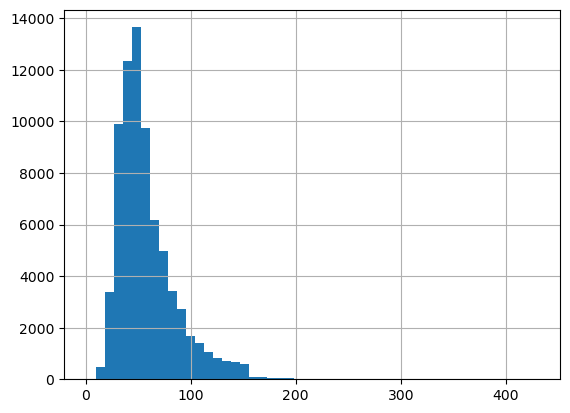

In [23]:
df['q1_len'].hist(bins=50)

generally question 1 length is avg 50

In [24]:
df['q2_len'] = df['question2'].str.len()

In [25]:
df[['q1_len','q2_len']].describe()

,q1_len,q2_len
count,74242.000000,74242.000000
mean,58.155815,58.492605
std,29.050014,31.603914
min,1.000000,1.000000
25%,39.000000,38.000000
50%,51.000000,50.000000
75%,70.000000,69.000000
max,430.000000,1151.000000


# word count analysis


In [26]:
df['q1_words']=df['question1'].apply(
    lambda x: len(str(x).split())
)

df['q2_words']=df['question2'].apply(
    lambda x: len(str(x).split())
)

In [27]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words
0,281827,401637,401638,The twins (Adarsh and Anupam) were born in May...,"Twins (Adarsh and Anupam) were born in May, bu...",1,98,95,18,17
1,119174,193562,193563,Why can't I bare to watch someone being humili...,How can you prove mean lifetime formula in rad...,0,129,61,22,10
2,18341,34756,2929,My questions haven't changed. Why are they now...,What happens to a question on Quora if it is m...,1,83,83,13,15
3,259132,374863,374864,"Can anyone tell the program for sequence 4,6,1...",What are the next three numbers in this series?,0,67,47,8,9
4,208109,312009,201015,If the civil war occurred today who would win?,If there was another US Civil War (North vs So...,1,46,78,9,16


In [28]:
df[['q1_words','q2_words']].describe()

,q1_words,q2_words
count,74242.000000,74242.000000
mean,10.721047,10.893995
std,5.255038,5.857431
min,1.000000,1.000000
25%,7.000000,7.000000
50%,9.000000,9.000000
75%,13.000000,13.000000
max,80.000000,237.000000


# Most Common words

In [29]:
from collections import Counter

all_text=" ".join(df['question1'].astype(str))

words=all_text.split()

Counter(words).most_common(20)

[('the', 33977),
 ('What', 26838),
 ('is', 19444),
 ('How', 19042),
 ('I', 18704),
 ('to', 17604),
 ('a', 17594),
 ('in', 16751),
 ('of', 14154),
 ('do', 12968),
 ('are', 12477),
 ('and', 11561),
 ('for', 8788),
 ('can', 8377),
 ('you', 7802),
 ('best', 6612),
 ('Why', 6429),
 ('my', 5930),
 ('on', 5401),
 ('it', 4815)]

In [30]:
def common_words(q1,q2):
    w1=set(str(q1).lower().split())
    w2=set(str(q2).lower().split())

    return len(w1.intersection(w2))

In [31]:
df['common_words']=df.apply(
    lambda row:
    common_words(
        row['question1'],
        row['question2']
    ),
    axis=1
)

In [32]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words
0,281827,401637,401638,The twins (Adarsh and Anupam) were born in May...,"Twins (Adarsh and Anupam) were born in May, bu...",1,98,95,18,17,14
1,119174,193562,193563,Why can't I bare to watch someone being humili...,How can you prove mean lifetime formula in rad...,0,129,61,22,10,0
2,18341,34756,2929,My questions haven't changed. Why are they now...,What happens to a question on Quora if it is m...,1,83,83,13,15,4
3,259132,374863,374864,"Can anyone tell the program for sequence 4,6,1...",What are the next three numbers in this series?,0,67,47,8,9,1
4,208109,312009,201015,If the civil war occurred today who would win?,If there was another US Civil War (North vs So...,1,46,78,9,16,6


In [33]:
df['common_words'].describe()

count    74242.000000
mean         4.715835
std          3.038968
min          0.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         35.000000
Name: common_words, dtype: float64

In [35]:
df = df.dropna()

df.to_csv(
    "../data/processed/sample_70k.csv",
    index=False
)

# Observations

- 4 lakh row but choose random 70k rows
- no null values
- made class distribution 50 50
- most questions have 50 to 70 words